# The Complete Effects of Coors Field

The goal of this project is to analyze the impact Coors Field, home park of the MLB team Colorodo Rockies, has on player performance. This is the abbreviated version of our final report; if you would like to see our full report, including additional visuals and a more comprehensive account of our thought process, go [HERE].

In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.ticker as mtick
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
from scipy.interpolate import make_interp_spline
from scipy.signal import savgol_filter
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.options.display.width = 0
pd.options.display.max_colwidth = 200
import warnings
warnings.filterwarnings(action='ignore')

## Coors Effect

### Park Altitudes

    [Code/visual]

Coors Field is located in Denver, Colorado where the altitude is roughly 5,200 feet above sea level, significantly higher than the altitudes of the rest of the MLB parks. This results in the air density at Coors Field being around 18% less than it is at sea level, significantly impacting the way the ball moves, both out of the pitcher's hand and off the bat.

In [ ]:
#statcast_2015 = pd.read_csv('statcast_2015.csv')
#statcast_2016 = pd.read_csv('statcast_2016.csv')
#statcast_2017 = pd.read_csv('statcast_2017.csv')
#statcast_2018 = pd.read_csv('statcast_2018.csv')
#statcast_2019 = pd.read_csv('statcast_2019.csv')
#statcast_2020 = pd.read_csv('statcast_2020.csv')
#statcast_2021 = pd.read_csv('statcast_2021.csv')
#statcast_2022 = pd.read_csv('statcast_2022.csv')
#statcast_2023 = pd.read_csv('statcast_2023.csv')
#statcast_2024 = pd.read_csv('statcast_2024.csv')
#statcast_2025 = pd.read_csv('statcast_2025.csv')

In [ ]:
#statcast_full = pd.concat([statcast_2015, statcast_2016, statcast_2017, statcast_2018, statcast_2019, statcast_2020, statcast_2021, statcast_2022, statcast_2023, statcast_2024, statcast_2025], ignore_index=True)

In [ ]:
#statcast_full.to_csv("statcast_full.csv", index=False)

NameError: name 'statcast_full' is not defined

In [2]:
df = pd.read_csv('statcast_full.csv')

In [5]:
df.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,spin_dir,spin_rate_deprecated,break_angle_deprecated,break_length_deprecated,zone,des,game_type,stand,p_throws,home_team,away_team,type,hit_location,bb_type,balls,strikes,game_year,pfx_x,pfx_z,plate_x,plate_z,on_3b,on_2b,on_1b,outs_when_up,inning,inning_topbot,hc_x,hc_y,tfs_deprecated,tfs_zulu_deprecated,umpire,sv_id,vx0,vy0,vz0,ax,ay,az,sz_top,sz_bot,hit_distance_sc,launch_speed,launch_angle,effective_speed,release_spin_rate,release_extension,game_pk,fielder_2,fielder_3,fielder_4,fielder_5,fielder_6,fielder_7,fielder_8,fielder_9,release_pos_y,estimated_ba_using_speedangle,estimated_woba_using_speedangle,woba_value,woba_denom,babip_value,iso_value,launch_speed_angle,at_bat_number,pitch_number,pitch_name,home_score,away_score,bat_score,fld_score,post_away_score,post_home_score,post_bat_score,post_fld_score,if_fielding_alignment,of_fielding_alignment,spin_axis,delta_home_win_exp,delta_run_exp,bat_speed,swing_length,estimated_slg_using_speedangle,delta_pitcher_run_exp,hyper_speed,home_score_diff,bat_score_diff,home_win_exp,bat_win_exp,age_pit_legacy,age_bat_legacy,age_pit,age_bat,n_thruorder_pitcher,n_priorpa_thisgame_player_at_bat,pitcher_days_since_prev_game,batter_days_since_prev_game,pitcher_days_until_next_game,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,FF,2015-11-01,96.1,-2.02,6.25,"Davis, Wade",527038,451584,strikeout,called_strike,NaN,NaN,NaN,NaN,13.0,Wilmer Flores called out on strikes.,W,R,R,NYM,KC,S,2.0,NaN,1,2,2015,-0.10,1.43,-0.93,1.62,NaN,624424.0,NaN,2,12,Bot,NaN,NaN,NaN,NaN,NaN,151102_003434,3.140108,-140.725594,-9.348185,-2.028,34.780,-11.706,3.54,1.56,NaN,NaN,NaN,95.4,2463.0,6.4,446277,460077,543333,450314,519058,444876,460086,456715,449181,54.5,NaN,0.0,0.0,1.0,0.0,0.0,NaN,94,6,4-Seam Fastball,2,7,2,7,7,2,2,7,Standard,Strategic,NaN,-0.001,-0.191,NaN,NaN,NaN,0.191,NaN,-5,-5,0.001,0.001,29,23,30,24,1,4,1.0,1.0,NaN,NaN,1.10,0.10,0.10,NaN,NaN,NaN,NaN,NaN,NaN
1,FC,2015-11-01,93.1,-1.66,6.24,"Davis, Wade",527038,451584,NaN,foul,NaN,NaN,NaN,NaN,9.0,Foul,W,R,R,NYM,KC,S,NaN,NaN,1,2,2015,0.50,0.45,0.78,1.55,NaN,624424.0,NaN,2,12,Bot,NaN,NaN,NaN,NaN,NaN,151102_003407,4.990328,-136.396666,-6.388609,5.004,28.835,-25.323,3.54,1.56,NaN,NaN,NaN,92.2,2705.0,5.9,446277,460077,543333,450314,519058,444876,460086,456715,449181,54.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94,5,Cutter,2,7,2,7,7,2,2,7,Standard,Strategic,NaN,0.000,0.000,NaN,NaN,NaN,0.000,NaN,-5,-5,0.001,0.001,29,23,30,24,1,4,1.0,1.0,NaN,NaN,2.21,-0.50,-0.50,NaN,NaN,NaN,NaN,NaN,NaN
2,FF,2015-11-01,97.0,-1.64,6.30,"Davis, Wade",527038,451584,NaN,foul,NaN,NaN,NaN,NaN,14.0,Foul,W,R,R,NYM,KC,S,NaN,NaN,1,2,2015,-0.27,1.18,1.32,2.47,NaN,624424.0,NaN,2,12,Bot,NaN,NaN,NaN,NaN,NaN,151102_003338,8.631302,-141.847487,-6.829429,-5.412,31.551,-15.189,3.54,1.56,NaN,NaN,NaN,96.4,2362.0,6.3,446277,460077,543333,450314,519058,444876,460086,456715,449181,54.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94,4,4-Seam Fastball,2,7,2,7,7,2,2,7,Standard,Strategic,NaN,0.000,0.000,NaN,NaN,NaN,0.000,NaN,-5,-5,0.001,0.001,29,23,30,24,1,4,1.0,1.0,NaN,NaN,1.28,0.27,0.27,NaN,NaN,NaN,NaN,NaN,NaN
3,FC,2015-11-01,93.6,-1.58,6.24,"Davis, Wade",527038,451584,NaN,ball,NaN,NaN,NaN,NaN,14.0,Ball,W,R,R,NYM,KC,B,NaN,NaN,0,2,2015,0.65,0.57,2.92,2.23,NaN,NaN,624424.0,2,12,Bot,NaN,NaN,NaN,NaN,NaN,151102_003312,9.893107,-136.604955,-5.019609,6.079,26.355,-24.250,3.54,1.56,NaN,NaN,NaN,92.8,2724.0,6.0,446277,460077,543333,450314,519058,444876,460086,456715,449181,54.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94,3,Cutter,2,7,2,7,7,2,2,7,Strategic,Strategic,NaN,0.000,0.019,NaN,NaN,NaN,-0.019,NaN,-5,-5,0.001,0.001,29,23,30,24,1,4,1.0,1.0,NaN,NaN,2.06,-0.65,-0.65,NaN,NaN,NaN,NaN,NaN,NaN
4,FF,2015-11-01,97.1,-1.70,6.30,"Davis, Wade",527038,451584,NaN,foul,NaN,NaN,NaN,Na

In [3]:
df_small = df.drop(['pitch_type', 'spin_dir', 'spin_rate_deprecated', 'break_angle_deprecated', 'break_length_deprecated', 'zone', 'type', 'bb_type', 'pfx_x', 'on_3b', 'on_2b', 'on_1b', 'tfs_deprecated', 'tfs_zulu_deprecated', 'umpire', 'sv_id', 'vx0', 'vy0', 'vz0', 'ax', 'ay', 'sz_top', 'sz_bot', 'effective_speed', 'fielder_2', 'fielder_3', 'fielder_4', 'fielder_5', 'fielder_6', 'fielder_7', 'fielder_8', 'fielder_9', 'release_pos_y', 'estimated_ba_using_speedangle', 'woba_denom', 'home_score', 'away_score', 'post_away_score', 'post_home_score', 'post_fld_score', 'spin_axis', 'delta_home_win_exp', 'delta_run_exp', 'bat_speed', 'swing_length', 'estimated_slg_using_speedangle', 'delta_pitcher_run_exp', 'hyper_speed', 'home_score_diff', 'bat_score_diff', 'home_win_exp', 'bat_win_exp', 'age_pit_legacy', 'age_bat_legacy', 'n_thruorder_pitcher', 'n_priorpa_thisgame_player_at_bat', 'pitcher_days_since_prev_game', 'batter_days_since_prev_game', 'pitcher_days_until_next_game', 'batter_days_until_next_game', 'api_break_x_batter_in', 'arm_angle', 'attack_angle', 'attack_direction', 'swing_path_tilt', 'intercept_ball_minus_batter_pos_x_inches', 'intercept_ball_minus_batter_pos_y_inches'], axis=1)
df_small = df_small.drop(['release_pos_x', 'release_pos_z', 'hit_location', 'az', 'release_extension', 'pitch_number'], axis=1)
df_small = df_small[df_small.game_type == 'R']

In [4]:
df_small.shape

(7412545, 45)

In [5]:
df_small.to_csv("statcast_red.csv", index=False)

In [4]:
df['bahb_value'] = df['babip_value']
df.loc[df['events'] == 'home_run', 'bahb_value'] = 1

df['plate_x_bucket'] = np.floor(df['plate_x'] / (5/18)) * (5/18) * 12
df['plate_z_bucket'] = np.floor((df['plate_z'] + 0.5) / (1/3)) * (1/3) * 12 - 6
df['zone_full'] = df.apply(lambda row: "inner heart" if (row['plate_x_bucket'] * 0.3 <= 0) & (row['plate_x_bucket'] * 0.3 >= -1) & (row['plate_z_bucket'] <= 30) & (row['plate_z_bucket'] >= 26)
                  else "heart" if (row['plate_x_bucket'] * 0.3 <= 1) & (row['plate_x_bucket'] * 0.3 >= -2) & (row['plate_z_bucket'] <= 34) & (row['plate_z_bucket'] >= 22)
                  else "shadow" if (row['plate_x_bucket'] * 0.3 <= 3) & (row['plate_x_bucket'] * 0.3 >= -4) & (row['plate_z_bucket'] <= 42) & (row['plate_z_bucket'] >= 14)
                  else "chase" if (row['plate_x_bucket'] * 0.3 <= 5) & (row['plate_x_bucket'] * 0.3 >= -6) & (row['plate_z_bucket'] <= 50) & (row['plate_z_bucket'] >= 6)
                  else "error" if (np.isnan(row['plate_x_bucket'])) | (np.isnan(row['plate_z_bucket']))
                  else "waste", axis=1)

col_df = df[(df.game_type == 'R') & (df['home_team'] == 'COL') & (df['events'].notna()) & (df['events'] != 'truncated_pa') & (df['estimated_woba_using_speedangle'] != '<NA>')]
mlb_df = df[(df.game_type == 'R') & (df['home_team'] != 'COL') & (df['events'].notna()) & (df['events'] != 'truncated_pa') & (df['estimated_woba_using_speedangle'] != '<NA>')]

### Pitch Movement

In [ ]:
min_pitches = 100

col_pitchers = df[(df.game_type == 'R') & ~(df.pfx_x.isna()) & (df.home_team == 'COL')].groupby(['player_name', 'pitch_name', 'game_year']).agg(
    pitch_count=('pitch_name', 'count'),
    horizontal_tot=('api_break_x_arm', 'mean'),
    vertical_tot=('api_break_z_with_gravity', 'mean'),
    vertical_ind=('pfx_z','mean')
).reset_index()

col_pitchers = col_pitchers[col_pitchers.pitch_count >= min_pitches]

mlb_pitchers = df[(df.game_type == 'R') & ~(df.pfx_x.isna()) & (df.home_team != 'COL')].groupby(['player_name', 'pitch_name', 'game_year']).agg(
    pitch_count=('pitch_name', 'count'),
    horizontal_tot=('api_break_x_arm', 'mean'),
    vertical_tot=('api_break_z_with_gravity', 'mean'),
    vertical_ind=('pfx_z','mean')
).reset_index()

mlb_pitchers = mlb_pitchers[mlb_pitchers.pitch_count >= min_pitches]

pitcher_movement = pd.merge(mlb_pitchers, col_pitchers, on=['player_name', 'pitch_name', 'game_year'], how='inner')
pitcher_movement['horizontal_tot_diff'] = pitcher_movement.horizontal_tot_y - pitcher_movement.horizontal_tot_x
pitcher_movement['vertical_tot_diff'] = pitcher_movement.vertical_tot_y - pitcher_movement.vertical_tot_x
pitcher_movement['vertical_ind_diff'] = pitcher_movement.vertical_ind_y - pitcher_movement.vertical_ind_x
movement_summary = pitcher_movement.groupby(['pitch_name']).agg(
    pitcher_count=('player_name', 'count'),
    pitch_count_mlb=('pitch_count_x', 'sum'),
    pitch_count_col=('pitch_count_y', 'sum'),
    horizontal_tot_mlb=('horizontal_tot_x', 'mean'),
    horizontal_tot_col=('horizontal_tot_y', 'mean'),
    horizontal_tot_diff=('horizontal_tot_diff', 'mean'),
    vertical_tot_mlb=('vertical_tot_x', 'mean'),
    vertical_tot_col=('vertical_tot_y', 'mean'),
    vertical_tot_diff=('vertical_tot_diff', 'mean'),
    vertical_ind_mlb=('vertical_ind_x', 'mean'),
    vertical_ind_col=('vertical_ind_y', 'mean'),
    vertical_ind_diff=('vertical_ind_diff', 'mean'),
).reset_index()

movement_summary['horizontal_tot_perc'] = movement_summary.horizontal_tot_diff / movement_summary.horizontal_tot_mlb
movement_summary['vertical_tot_perc'] = movement_summary.vertical_tot_diff / movement_summary.vertical_tot_mlb
movement_summary['vertical_ind_perc'] = movement_summary.vertical_ind_diff / movement_summary.vertical_ind_mlb

movement_summary['horizontal_tot_mlb'] = round(movement_summary['horizontal_tot_mlb'], 2)
movement_summary['horizontal_tot_col'] = round(movement_summary['horizontal_tot_col'], 2)
movement_summary['horizontal_tot_diff'] = round(movement_summary['horizontal_tot_diff'], 2)
movement_summary['horizontal_tot_perc'] = movement_summary['horizontal_tot_perc'].apply(lambda x: f"{x:.0%}")

movement_summary['vertical_tot_mlb'] = round(movement_summary['vertical_tot_mlb'], 2)
movement_summary['vertical_tot_col'] = round(movement_summary['vertical_tot_col'], 2)
movement_summary['vertical_tot_diff'] = round(movement_summary['vertical_tot_diff'], 2)
movement_summary['vertical_tot_perc'] = movement_summary['vertical_tot_perc'].apply(lambda x: f"{x:.0%}")

movement_summary['vertical_ind_mlb'] = round(movement_summary['vertical_ind_mlb'], 2)
movement_summary['vertical_ind_col'] = round(movement_summary['vertical_ind_col'], 2)
movement_summary['vertical_ind_diff'] = round(movement_summary['vertical_ind_diff'], 2)
movement_summary['vertical_ind_perc'] = movement_summary['vertical_ind_perc'].apply(lambda x: f"{x:.0%}")

In [ ]:
movement_summary[movement_summary.pitcher_count >= 0][['pitch_name', 'pitcher_count', 'horizontal_tot_mlb', 'horizontal_tot_perc', 'vertical_ind_mlb', 'vertical_ind_perc']].sort_values(by='pitcher_count', ascending=False)

,pitch_type,pitcher_count,horizontal_tot_mlb,horizontal_tot_perc,vertical_ind_mlb,vertical_ind_perc
3,FF,157,0.63,-22%,1.31,-18%
7,SL,66,-0.32,-6%,0.23,-20%
6,SI,60,1.23,-22%,0.65,-14%
0,CH,37,1.05,-21%,0.60,-19%
2,FC,34,-0.18,-14%,0.59,-19%
1,CU,24,-0.88,-17%,-0.61,-16%
5,KC,18,-0.46,-32%,-0.66,-24%
8,ST,9,-1.22,-13%,0.23,-67%
4,FS,3,1.04,-26%,0.25,-3%


Let's start with how Coors effects movement out of the pitcher's hand. Since pitches move differently depending on the pitcher and pitch type, we grouped pitches by these variables, as well as year to account for changes over time, and split them by when they were thrown at Coors Field vs. all other parks (AOP). Looking at pitchers with at least 100 pitches at both Coors and AOP, we calculated the straight average movement at AOP and how much less the average movement at Coors is. From this, we can see that pitches move less both horizontally and vertically at Coors. Pitches move due to air resistance (drag) and the Magnus effect, which uses air density to create the force of lift and break. Because of the altitude, air density in Denver is roughly 18% lower than the air density at sea level, though other factors like temperature and humidity have an effect as well. Pitch movement should be directly proportional to air density, and our findings support that.

### Pitch Placement

It's unclear how much Coors Field affects pitch placement. Pitchers almost certainly know about the reduced pitch movement and account for it. Plus pitchers likely account for the heightened offensive production at Coors. Add in the variation in where pitchers aim their pitches and their execution of intended placement, and there's too much noise to make many conclusions.

### Swing Outcomes

In [67]:
swing_list = ['hit_into_play', 'foul', 'foul_tip', 'foul_pitchout', 'swinging_pitchout', 'swinging_strike', 'swinging_strike_blocked']
miss_list = ['swinging_pitchout', 'swinging_strike', 'swinging_strike_blocked']
foul_list = ['foul', 'foul_tip', 'foul_pitchout']
swings = df[(df.game_type == 'R') & (df.description.isin(swing_list))]
swings['Coors'] = swings.apply(lambda row: 'Coors' if row['home_team'] == 'COL' else 'AOP', axis=1)
swings['Result'] = swings.apply(lambda row: 'Whiff' if row['description'] in miss_list else 'Foul' if row['description'] in foul_list else 'In Play' if row['description'] == 'hit_into_play' else 'error', axis=1)
#print(len(swings[(df.home_team == 'COL') & (df.description.isin(miss_list))]) / len(swings[df.home_team == 'COL']))
#print(len(swings[(df.home_team != 'COL') & (df.description.isin(miss_list))]) / len(swings[df.home_team != 'COL']))
#print(len(swings[(df.home_team == 'COL') & (df.description.isin(foul_list))]) / len(swings[df.home_team == 'COL']))
#print(len(swings[(df.home_team != 'COL') & (df.description.isin(foul_list))]) / len(swings[df.home_team != 'COL']))

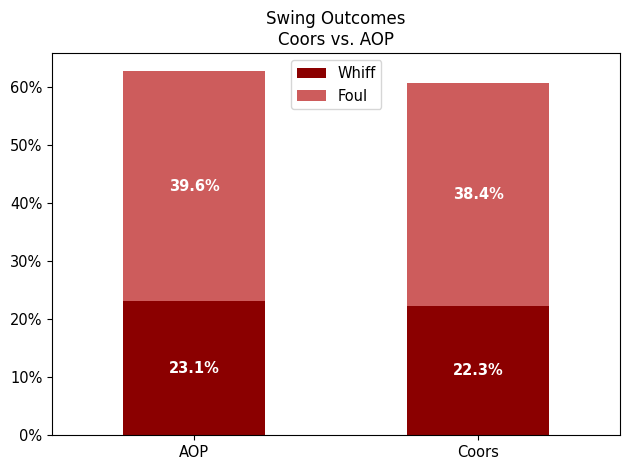

In [107]:
swing_order = ['Whiff', 'Foul', 'In Play']
swing_table = pd.crosstab(swings['Coors'], swings['Result'], normalize='index')
swing_table.columns = pd.CategoricalIndex(swing_table.columns.values, ordered=True, categories=swing_order)
swing_table = swing_table.sort_index(axis=1)
#swing_table.style.format({'Whiff': '{:.1%}', 'Foul': '{:.1%}', 'In Play': '{:.1%}'})
bars = swing_table.drop('In Play', axis=1).plot(kind='bar', stacked=True, color=['darkred', 'indianred'])
#sns.histplot(data=swings, x='Coors', hue='Result', multiple='stack')
# Add data labels
for container in bars.containers:
    bars.bar_label(container, fmt='{:.1%}', label_type='center', color='white', size=10.5, fontweight='bold') # Format as percentage
plt.title('Swing Outcomes\nCoors vs. AOP')
plt.tick_params(axis='x', labelrotation=0, labelsize=10.5)
plt.xlabel('')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
plt.yticks(fontsize=10.5)
plt.legend(loc='upper center', fontsize=10.5)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig("swing_outcomes.png", dpi=300)
plt.show()

At Coors Field, swings result in a ball in play roughly 2% more of the time. This may be due to the reduced pitch movement making it easier to make contact, though it may in part be due to the slightly increased rate of pitches in the heart of the strike zone (which also may be due to the reduced pitch movement).

## Off the Bat

In [ ]:
pitch_types = df[(df.game_type == 'R') & ~(df.pfx_z.isna())].groupby(['pitch_name']).agg(
    vertical_ind=('pfx_z','mean')
).reset_index()
#pitch_types[pitch_types.vertical_ind > 0].pitch_type

In [110]:
col_df_ip = col_df[(col_df['description'] == 'hit_into_play') & 
                   ((col_df['game_year'] >= 2020) |
                   (((col_df['launch_speed'] != 80) | (col_df['launch_angle'] != 69)) &
                   ((col_df['launch_speed'] != 82.9) | (col_df['launch_angle'] != -21)) &
                   ((col_df['launch_speed'] != 89.2) | (col_df['launch_angle'] != 39)) &
                   ((col_df['launch_speed'] != 90.3) | (col_df['launch_angle'] != -17))))]
mlb_df_ip = mlb_df[(mlb_df['description'] == 'hit_into_play') & 
                   ((mlb_df['game_year'] >= 2020) |
                   (((mlb_df['launch_speed'] != 80) | (mlb_df['launch_angle'] != 69)) &
                   ((mlb_df['launch_speed'] != 82.9) | (mlb_df['launch_angle'] != -21)) &
                   ((mlb_df['launch_speed'] != 89.2) | (mlb_df['launch_angle'] != 39)) &
                   ((mlb_df['launch_speed'] != 90.3) | (mlb_df['launch_angle'] != -17))))]

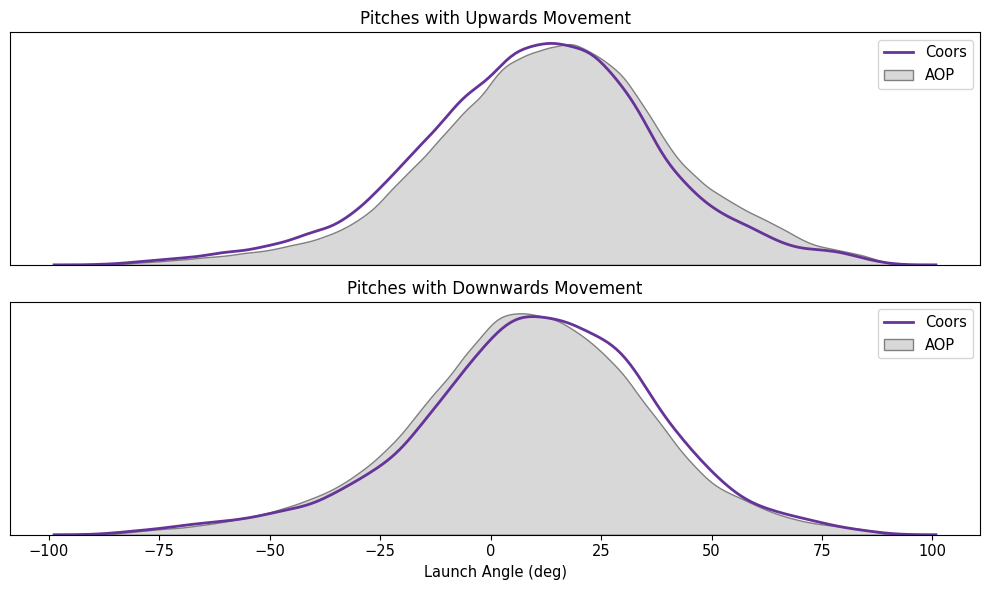

In [325]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(10, 6))
#plt.figure(figsize=(10, 6))
sns.kdeplot(col_df_ip[col_df_ip.pfx_z > 0]['launch_angle'], color='rebeccapurple', label='Coors', fill=False, linewidth=2, ax=ax1)
sns.kdeplot(mlb_df_ip[mlb_df_ip.pfx_z > 0]['launch_angle'], color='gray', label='AOP', fill=True, alpha=0.3, ax=ax1)
#sns.kdeplot(col_df_ip[col_df_ip.pitch_type.isin(pitch_types[pitch_types.vertical_ind > 0].pitch_type)]['launch_angle'], color='blue', label='Coors', alpha=0.5)
#sns.kdeplot(mlb_df_ip[mlb_df_ip.pitch_type.isin(pitch_types[pitch_types.vertical_ind > 0].pitch_type)]['launch_angle'], color='red', label='AOP', alpha=0.5)
ax1.set_title('Pitches with Upwards Movement')
ax1.set_xlabel('')
ax1.set_xticks([])
ax1.set_ylabel('')
ax1.set_yticks([])
ax1.legend(fontsize=10.5)

sns.kdeplot(col_df_ip[col_df_ip.pfx_z <= 0]['launch_angle'], color='rebeccapurple', label='Coors', fill=False, linewidth=2, ax=ax2)
sns.kdeplot(mlb_df_ip[mlb_df_ip.pfx_z <= 0]['launch_angle'], color='gray', label='AOP', fill=True, alpha=0.3, ax=ax2)
#sns.kdeplot(col_df_ip[col_df_ip.pitch_type.isin(pitch_types[pitch_types.vertical_ind <= 0].pitch_type)]['launch_angle'], color='blue', label='Coors', alpha=0.5)
#sns.kdeplot(mlb_df_ip[mlb_df_ip.pitch_type.isin(pitch_types[pitch_types.vertical_ind <= 0].pitch_type)]['launch_angle'], color='red', label='AOP', alpha=0.5)
ax2.set_title('Pitches with Downwards Movement')
ax2.set_xlabel('Launch Angle (deg)', fontsize=10.5)
ax2.tick_params(axis='x', labelsize=10.5)
ax2.set_ylabel('')
ax2.set_yticks([])
ax2.legend(fontsize=10.5)

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig("la_dist.png", dpi=300)
plt.show()

For pitches with upwards induced movement, the reduced movement at Coors causes the pitches to arrive lower than they appear to be going. As a result, batters tend to get on top of the ball more at Coors, resulting in a lower distribution of launch angles from batted balls at Coors. On the other hand, pitches with downwards induced movement see the opposite effect. The reduced movement at Coors causes these pitches to arrive higher than they appear to be going, resulting in batter getting under the ball and thus a higher distribution of launch angles. Given that the majority of pitches have upwards induced movement, this phenomenon results in more balls in play with low launch angles (i.e. groundballs).

### Hit Distance

Hitters may tend to get on top of the ball more often at Coors, but when they do put it in the air, the lower air density works in their favor. With less air to slow the ball down, it ends up carrying more.

In [137]:
step = 5
min_count = 10

col_df_ip['ev_bucket'] = np.floor(col_df_ip['launch_speed'] / step) * step
col_df_ip['la_bucket'] = np.floor(col_df_ip['launch_angle'] / step) * step
col_statcast_full = col_df_ip.groupby(['ev_bucket', 'la_bucket']).agg(
    dist_col=('hit_distance_sc', 'mean'),
    count_col=('hit_distance_sc', 'count'),
    babip_col=('babip_value', 'mean'),
    bahb_col=('bahb_value', 'mean'),
    iso_col=('iso_value', 'mean'),
    woba_col=('woba_value', 'mean'),
    xwoba_col=('estimated_woba_using_speedangle', 'mean')
).reset_index()

mlb_df_ip['ev_bucket'] = np.floor(mlb_df_ip['launch_speed'] / step) * step
mlb_df_ip['la_bucket'] = np.floor(mlb_df_ip['launch_angle'] / step) * step
mlb_statcast_full = mlb_df_ip.groupby(['ev_bucket', 'la_bucket']).agg(
    dist_mlb=('hit_distance_sc', 'mean'),
    count_mlb=('hit_distance_sc', 'count'),
    babip_mlb=('babip_value', 'mean'),
    bahb_mlb=('bahb_value', 'mean'),
    iso_mlb=('iso_value', 'mean'),
    woba_mlb=('woba_value', 'mean'),
    xwoba_mlb=('estimated_woba_using_speedangle', 'mean')
).reset_index()

statcast = pd.merge(col_statcast_full, mlb_statcast_full, on=['ev_bucket', 'la_bucket'], how='inner')
statcast['distance_gap'] = statcast['dist_col'] - statcast['dist_mlb']
statcast['distance_gap_perc'] = statcast['distance_gap'] / statcast['dist_mlb'] * 100
statcast['babip_gap'] = statcast['babip_col'] - statcast['babip_mlb']
statcast['bahb_gap'] = statcast['bahb_col'] - statcast['bahb_mlb']
statcast['iso_gap'] = statcast['iso_col'] - statcast['iso_mlb']
statcast['woba_gap'] = statcast['woba_col'] - statcast['woba_mlb']
statcast['xwoba_gap'] = statcast['xwoba_col'] - statcast['xwoba_mlb']
statcast['ev_bucket'] = statcast['ev_bucket'].astype(int)
statcast['la_bucket'] = statcast['la_bucket'].astype(int)

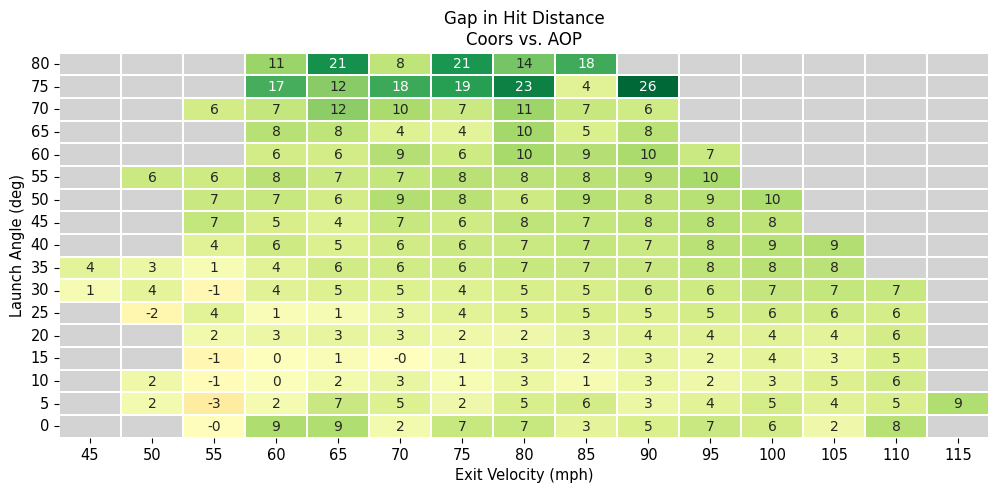

In [336]:
dist_gap_pivot = statcast[statcast['count_col'] >= min_count].pivot(index='la_bucket', columns='ev_bucket', values='distance_gap_perc')
#gap_pivot[pd.isna(gap_pivot)] = 0.0
dist_gap_pivot = dist_gap_pivot.astype(float)
dist_gap_pivot_pos = dist_gap_pivot[dist_gap_pivot.index >= 0].dropna(axis='columns', how='all')

limit = max(np.max(dist_gap_pivot_pos), np.min(dist_gap_pivot_pos), key=abs)
divnorm = colors.TwoSlopeNorm(vmin = -1 * limit, vcenter = 0, vmax = limit)

fig, ax = plt.subplots(figsize = (12, 5))
ax = sns.heatmap(dist_gap_pivot_pos, cmap = 'RdYlGn', norm=divnorm, linewidths = 0.01, annot = True, fmt = ".0f", cbar=False)
ax.set_facecolor('lightgray')
ax.invert_yaxis()
ax.set_title('Gap in Hit Distance\nCoors vs. AOP')
ax.set_ylabel('Launch Angle (deg)', fontsize=10.5)
ax.set_xlabel('Exit Velocity (mph)', fontsize=10.5)
ax.tick_params(axis='both', labelsize=10.5)
plt.tick_params(axis='y', labelrotation=0)
#ymin, ymax = ax.get_ylim()
#ax.set_yticklabels(np.arange(ymin, ymax, 2))
plt.savefig("hit_dist_gap.png", dpi=300)
plt.show()

Controlling for the batted ball's launch angle and exit velocity, balls in Colorado consistently travel farther in the air, with a larger gap for balls with further hit distances.

In [274]:
mlb_hit_dist = mlb_df_ip.groupby(['hit_distance_sc']).agg(
    count_mlb=('hit_distance_sc', 'count'),
    babip_mlb=('babip_value', 'mean'),
    bahb_mlb=('bahb_value', 'mean'),
    iso_mlb=('iso_value', 'mean'),
    woba_mlb=('woba_value', 'mean'),
    xwoba_mlb=('estimated_woba_using_speedangle', 'mean')
).reset_index()

col_hit_dist = col_df_ip.groupby(['hit_distance_sc']).agg(
    count_mlb=('hit_distance_sc', 'count'),
    babip_mlb=('babip_value', 'mean'),
    bahb_mlb=('bahb_value', 'mean'),
    iso_mlb=('iso_value', 'mean'),
    woba_mlb=('woba_value', 'mean'),
    xwoba_mlb=('estimated_woba_using_speedangle', 'mean')
).reset_index()

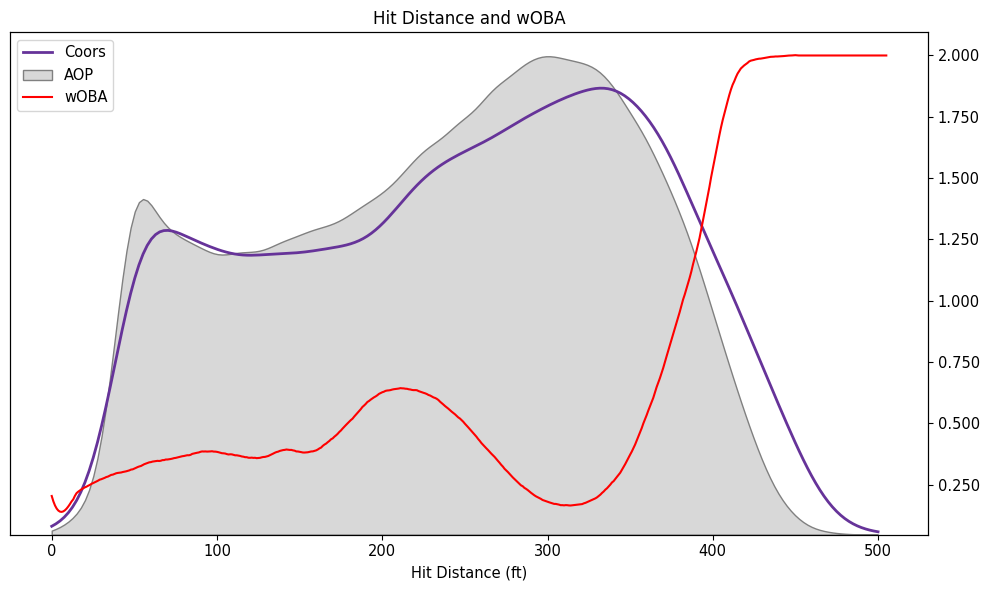

In [328]:
window_length = 25
polyorder = 3

fig, ax1 = plt.subplots(figsize=(10, 6))
#plt.figure(figsize=(10, 6))
lns1 = sns.kdeplot(col_df_ip[col_df_ip['la_bucket'] >= 0]['hit_distance_sc'], color='rebeccapurple', label='Coors', fill=False, linewidth=2, clip=(0, 500), ax=ax1)
lns2 = sns.kdeplot(mlb_df_ip[mlb_df_ip['la_bucket'] >= 0]['hit_distance_sc'], color='gray', label='AOP', fill=True, alpha=0.3, clip=(0, 500), ax=ax1)

#sns.kdeplot(col_df_ip[col_df_ip.pitch_type.isin(pitch_types[pitch_types.vertical_ind > 0].pitch_type)]['launch_angle'], color='blue', label='Coors', alpha=0.5)
#sns.kdeplot(mlb_df_ip[mlb_df_ip.pitch_type.isin(pitch_types[pitch_types.vertical_ind > 0].pitch_type)]['launch_angle'], color='red', label='AOP', alpha=0.5)
ax1.set_title('Hit Distance and wOBA')
ax1.set_ylabel('')
ax1.set_yticks([])
ax1.set_xlabel('Hit Distance (ft)', fontsize=10.5)
ax1.tick_params(axis='x', labelsize=10.5)
#ax1.legend(loc='upper left', fontsize=10.5)

ax2 = ax1.twinx()

#spl = make_interp_spline(mlb_hit_dist['hit_distance_sc'], mlb_hit_dist['bahb_mlb'], k=3)
#dist_smooth = np.linspace(mlb_hit_dist['hit_distance_sc'].min(), mlb_hit_dist['hit_distance_sc'].max(), 50)
#bahb_smooth = spl(dist_smooth)
lns3 = ax2.plot(mlb_hit_dist['hit_distance_sc'], savgol_filter(mlb_hit_dist['woba_mlb'], window_length, polyorder), color='red', label='wOBA')
#lns3 = ax2.plot(mlb_hit_dist['hit_distance_sc'], mlb_hit_dist['woba_mlb'], color='red', label='wOBA')
#ax2.plot(mlb_hit_dist['hit_distance_sc'], mlb_hit_dist['bahb_mlb'], label='BAHB')
#ax2.legend(loc='upper left', fontsize=10.5)
ax2.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
ax2.tick_params(axis='y', labelsize=10.5)

lns = lns1.get_legend_handles_labels()[0]+lns3
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc='upper left', fontsize=10.5)

fig.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig("hit_dist_woba.png", dpi=300)
plt.show()

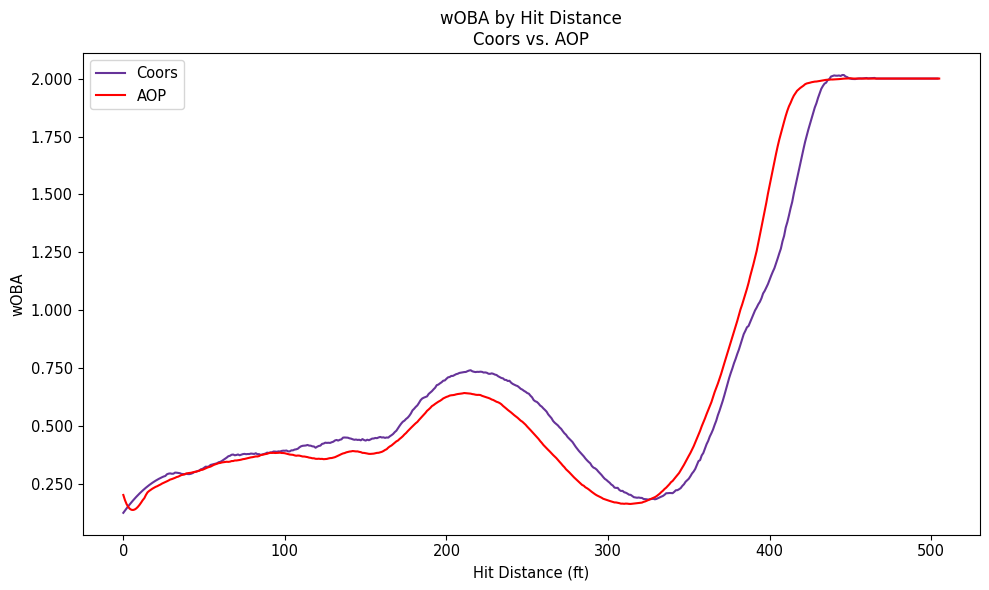

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(col_hit_dist['hit_distance_sc'], savgol_filter(col_hit_dist['woba_mlb'], window_length*2+1, polyorder), color='rebeccapurple', label='Coors')
ax.plot(mlb_hit_dist['hit_distance_sc'], savgol_filter(mlb_hit_dist['woba_mlb'], window_length, polyorder), color='red', label='AOP')
#ax.plot(col_hit_dist['hit_distance_sc'], col_hit_dist['woba_mlb'], label='Coors2')
#ax.plot(mlb_hit_dist['hit_distance_sc'], mlb_hit_dist['woba_mlb'], label='AOP2')
ax.set_title('wOBA by Hit Distance\nCoors vs. AOP')
ax.set_ylabel('wOBA', fontsize=10.5)
ax.set_xlabel('Hit Distance (ft)', fontsize=10.5)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
ax.tick_params(axis='both', labelsize=10.5)
ax.legend(loc='upper left', fontsize=10.5)

fig.tight_layout() # Adjust layout to prevent labels from overlapping
plt.savefig("hit_dist_woba2.png", dpi=300)
plt.show()

While outfielders tend to position themselves around 315 feet away from home plate in AOP, at Coors they're around 330 feet away to compensate for the larger outfield. As a result, batted balls that go around 200-300 feet drop for hits at Coors more often, as the outfielders are farther away.

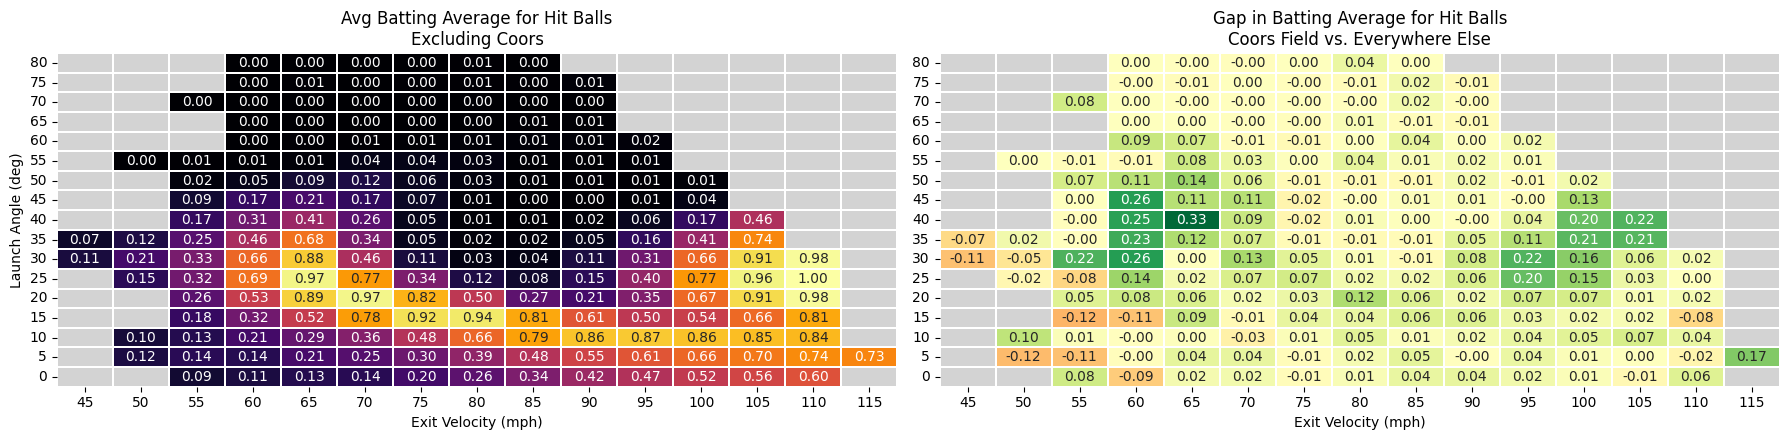

In [208]:
bahb_pivot = statcast[statcast['count_col'] >= min_count].pivot(index='la_bucket', columns='ev_bucket', values='bahb_mlb')
#dist_pivot[pd.isna(dist_pivot)] = 0.0
bahb_pivot = bahb_pivot.astype(float)
bahb_pivot_pos = bahb_pivot[bahb_pivot.index >= 0].dropna(axis='columns', how='all')

#limit = max(list(dist_pivot.max()) + list(dist_pivot.min()), key=abs)
#divnorm = colors.TwoSlopeNorm(vmin = -1 * limit, vcenter = 0, vmax = limit)

bahb_gap_pivot = statcast[statcast['count_col'] >= min_count].pivot(index='la_bucket', columns='ev_bucket', values='bahb_gap')
#gap_pivot[pd.isna(gap_pivot)] = 0.0
bahb_gap_pivot = bahb_gap_pivot.astype(float)
bahb_gap_pivot_pos = bahb_gap_pivot[bahb_gap_pivot.index >= 0].dropna(axis='columns', how='all')

limit = max(list(bahb_gap_pivot_pos.max()) + list(bahb_gap_pivot_pos.min()), key=abs)
divnorm = colors.TwoSlopeNorm(vmin = -1 * limit, vcenter = 0, vmax = limit)

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 4.5))
ax1 = sns.heatmap(bahb_pivot_pos, cmap = 'inferno', linewidths = 0.01, annot = True, fmt = ".2f", cbar=False, ax=ax1)
ax1.set_facecolor('lightgray')
ax1.invert_yaxis()
ax1.set_title('Avg Batting Average for Hit Balls\nExcluding Coors')
ax1.set_ylabel('Launch Angle (deg)')
ax1.tick_params(axis='y', labelrotation=0)
ax1.set_xlabel('Exit Velocity (mph)')

ax2 = sns.heatmap(bahb_gap_pivot_pos, cmap = 'RdYlGn', norm=divnorm, linewidths = 0.01, annot = True, fmt = ".2f", cbar=False, ax=ax2)
ax2.set_facecolor('lightgray')
ax2.invert_yaxis()
ax2.set_title('Gap in Batting Average for Hit Balls\nCoors Field vs. Everywhere Else')
ax2.set_ylabel('')
ax2.tick_params(axis='y', labelrotation=0)
ax2.set_xlabel('Exit Velocity (mph)')

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### Basic Offensive Performance

To see how the difference in altitude impacts offense, we have several performance metrics here.

First we want to see if there's any noticeable effect that Coors has on player performance. We have several performance metrics here. Batting Average for Balls In Play (BABIP) are the proportion of ball in play that result in hits. So essentially batting average for everything except home runs and strikeouts. HR%, K%, and BB% are the percentage of plate appearances that resulted in a home run, strikeout, and walk, respectively. Isolated power (ISO) represents the propensity for extra bases. It's calculated as [SLG - AVG]. Lastly, R/PA is the number of runs per plate appearance. We used this abnormal metric instead of the more standard ERA or RA simply because there wasn't an easy way to calculate the number of outs using Statcast data.

We split performance on these metrics by games at Coors Field and games at all other parks (AOP) for 2015-2025. Offense at Coors performs better across the board, culminating in R/PA being ~20% higher at Coors than AOP. That's pretty compelling, but it's possible that the Colorado Rockies consist of better batters (or worse pitchers) than the rest of the league. Roughly half of the plate appearances at Coors are theirs after all. So next we'll take a look at those same metrics but filtered to only the road teams. So for Coors Field, that's everyone but the Rockies. We get pretty much the same results, though it is again possible that this is being caused by a discrepancy in the level of pitchers and batters playing at Coors versus playing elsewhere. NL West teams play more games at Coors than other National League teams, and they play way more games at Coors than American League teams, so again we have biases in the data. One way to handle this is by comparing performance at Coors vs. AOP at the team level. It would be a bit overkill to do this with each team, so let's just do it with the Rockies themselves. This is performance for the Rockies when playing at home (Coors Field) and playing away (AOP). This 

In [337]:
metrics = ['BABIP', 'HR%', 'ISO', 'K%', 'BB%', 'R/PA']
col_df_away = col_df[col_df['inning_topbot'] == 'Top']
mlb_df_away = mlb_df[mlb_df['inning_topbot'] == 'Top']

col_metrics_away = ["{:.3}".format(col_df_away[(col_df_away['description'] == 'hit_into_play') & (col_df_away['events'] != 'home_run')]['babip_value'].mean()).lstrip('0'),
                    "{:.1%}".format(len(col_df_away[col_df_away['events'] == 'home_run']) / len(col_df_away)),
                    "{:.3}".format(col_df_away[col_df_away['description'] == 'hit_into_play']['iso_value'].mean()).lstrip('0'),
                    "{:.1%}".format(len(col_df_away[col_df_away['events'] == 'strikeout']) / len(col_df_away)),
                    "{:.1%}".format(len(col_df_away[col_df_away['events'] == 'walk']) / len(col_df_away)),
                    "{:.3}".format(col_df_away[col_df_away['description'] == 'hit_into_play']['post_bat_score'].mean() - col_df_away[col_df_away['description'] == 'hit_into_play']['bat_score'].mean()).lstrip('0')]
mlb_metrics_away = ["{:.3}".format(mlb_df_away[(mlb_df_away['description'] == 'hit_into_play') & (mlb_df_away['events'] != 'home_run')]['babip_value'].mean()).lstrip('0'),
                    "{:.1%}".format(len(mlb_df_away[mlb_df_away['events'] == 'home_run']) / len(mlb_df_away)),
                    "{:.3}".format(mlb_df_away[mlb_df_away['description'] == 'hit_into_play']['iso_value'].mean()).lstrip('0'),
                    "{:.1%}".format(len(mlb_df_away[mlb_df_away['events'] == 'strikeout']) / len(mlb_df_away)),
                    "{:.1%}".format(len(mlb_df_away[mlb_df_away['events'] == 'walk']) / len(mlb_df_away)),
                    "{:.3}".format(mlb_df_away[mlb_df_away['description'] == 'hit_into_play']['post_bat_score'].mean() - mlb_df_away[mlb_df_away['description'] == 'hit_into_play']['bat_score'].mean()).lstrip('0')]

off_table = pd.DataFrame()
off_table[''] = metrics
off_table['Coors'] = col_metrics_away
off_table['All Other Parks'] = mlb_metrics_away

print(off_table.to_string(index=False))

      Coors All Other Parks
BABIP  .325             .29
  HR%  3.4%            3.1%
  ISO  .238            .209
   K% 18.7%           22.7%
  BB%  8.1%            7.7%
 R/PA    .2            .162


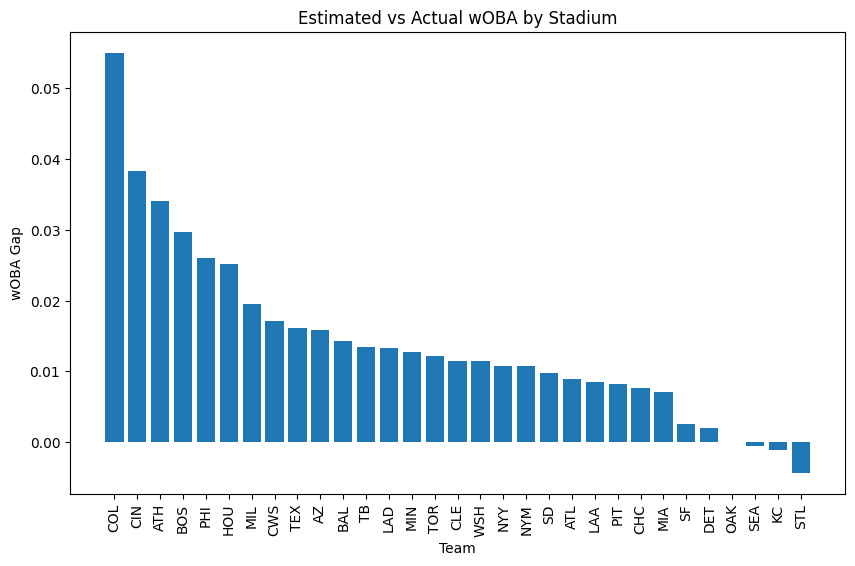

In [ ]:
tot_df_ip = df[(df.game_type == 'R') & (df['description'] == 'hit_into_play') & (df['events'].notna()) & (df['events'] != 'truncated_pa') & (df['estimated_woba_using_speedangle'] != '<NA>') & 
                   ((df['game_year'] >= 2020) |
                   (((df['launch_speed'] != 80) | (df['launch_angle'] != 69)) &
                   ((df['launch_speed'] != 82.9) | (df['launch_angle'] != -21)) &
                   ((df['launch_speed'] != 89.2) | (df['launch_angle'] != 39)) &
                   ((df['launch_speed'] != 90.3) | (df['launch_angle'] != -17))))]
tot_df_ip['wOBA Gap'] = tot_df_ip['woba_value'] - tot_df_ip['estimated_woba_using_speedangle']
team_gaps = tot_df_ip.groupby('home_team')['wOBA Gap'].mean()
team_gaps = team_gaps.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(team_gaps.index, team_gaps.values)
plt.title('Expected vs Actual wOBA by Stadium')
plt.xlabel('Team')
plt.ylabel('wOBA Gap')
plt.xticks(rotation=90)
plt.savefig("woba_park.png", dpi=300)
plt.show()